# 10.2. Gated Recurrent Units (GRU)

## 📘 Code Along

In [9]:
import torch
from torch import nn

import sys
sys.path.append("../..")
from dataloaders import TimeMachine
from models import RNNLMScratch, RNNLM, RNN
from utils import Module, Trainer

### 10.2.1. Reset Gate and Update Gate

### 10.2.2. Candidate Hidden State

### 10.2.3. Hidden State

### 10.2.4. Implementation from Scratch

In [6]:
class GRUScratch(Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()

        init_weight = lambda *shape: nn.Parameter(torch.randn(*shape) * sigma)
        triple = lambda: (init_weight(num_inputs, num_hiddens),
                          init_weight(num_hiddens, num_hiddens),
                          nn.Parameter(torch.zeros(num_hiddens)))
        self.W_xz, self.W_hz, self.b_z = triple()  # Update gate
        self.W_xr, self.W_hr, self.b_r = triple()  # Reset gate
        self.W_xh, self.W_hh, self.b_h = triple()  # Candidate hidden state

    def forward(self, inputs, H=None):
        if H is None:
            # Initial state with shape: (batch_size, num_hiddens)
            H = torch.zeros((inputs.shape[1], self.num_hiddens),
                        device=inputs.device)
        outputs = []
        for X in inputs:
            Z = torch.sigmoid(torch.matmul(X, self.W_xz) +
                            torch.matmul(H, self.W_hz) + self.b_z)
            R = torch.sigmoid(torch.matmul(X, self.W_xr) +
                            torch.matmul(H, self.W_hr) + self.b_r)
            H_tilde = torch.tanh(torch.matmul(X, self.W_xh) +
                            torch.matmul(R * H, self.W_hh) + self.b_h)
            H = Z * H + (1 - Z) * H_tilde
            outputs.append(H)
        return outputs, H

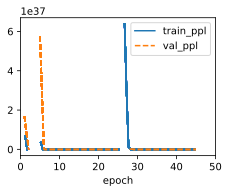

In [7]:
data = TimeMachine(batch_size=1024, num_steps=32)
gru = GRUScratch(num_inputs=len(data.vocab), num_hiddens=32)
model = RNNLMScratch(gru, vocab_size=len(data.vocab), lr=4)
trainer = Trainer(max_epochs=50, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

### 10.2.5. Concise Implementation

In [10]:
class GRU(RNN):
    def __init__(self, num_inputs, num_hiddens):
        Module.__init__(self)
        self.save_hyperparameters()
        self.rnn = nn.GRU(num_inputs, num_hiddens)

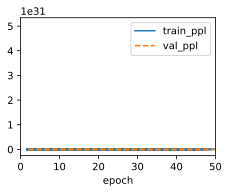

In [11]:
gru = GRU(num_inputs=len(data.vocab), num_hiddens=32)
model = RNNLM(gru, vocab_size=len(data.vocab), lr=4)
trainer.fit(model, data)

In [12]:
model.predict('it has', 20, data.vocab, torch.device(f'mps:{1}'))

'it hastttttttttttttttttttt'